In [26]:
import h3
import geopandas
import h3pandas
import numpy as np 
import math
import decimal
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as sm_formula
from shapely import geometry
from scipy import stats

In [27]:
def plot_df(df, column=None, ax=None, cmap=None):
    "Plot based on the `geometry` column of a GeoPandas dataframe"
    df = df.copy()
    df = df.to_crs(epsg=3857)  # web mercator

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # print("cmap", cmap)
    # print(cmap is None)

    if cmap is None:
        legend_kwds = {'loc': 'upper left'}
    else:
        legend_kwds = {'shrink': 0.6}

    df.plot(
        ax=ax,
        alpha=0.5, edgecolor='k',
        column=column, categorical=(cmap is None),cmap=cmap,
        legend=True, legend_kwds=legend_kwds,
    )
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)

In [28]:
def plot_df_side_by_side(dfs, columns=None, cmap=None):
    count = len(dfs)
    _, axs = plt.subplots(1, count, figsize=(20, 7))
    for df, col, ax in zip(dfs, columns, axs):
        plot_df(df, column=col, ax=ax, cmap=cmap)
        

In [29]:
def compare_choropleths(df, variables,cmap="inferno",alpha=0.7,legend=True,legend_kwds={'shrink': 0.6}):
    count = len(variables)
    _, axs = plt.subplots(1, count, figsize=(20, 7))
    for var, ax in zip(variables,axs):
        df.plot(
            column=var,
            cmap=cmap,
            alpha=alpha,
            legend=legend,
            legend_kwds=legend_kwds,
            ax=ax
        )
        cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

# Sewer repair analysis



## About the data

### Target Variable: Sewer Repair alerts

Using alerts scraped from the WSSC website

Scraped using [this utility](https://github.com/emmafurth/WSSCAlertsScraper)

In [30]:
wssc_path = "Datasets/WSSC_Alerts/wssc_alerts_geocoded.shp"
wssc_alerts = geopandas.read_file(wssc_path)
wssc_alerts = wssc_alerts[["title", "date", "pipe_diame", "address", "geometry"]]
wssc_alerts.head()

,title,date,pipe_diame,address,geometry
0,Emergency Water Main Repair - Takoma Park,"December 30, 2022",8,"602 Ethan Allen Avenue, Takoma Park",POINT (-76.99652 38.97612)
1,Emergency Water Main Repair - Capitol Heights,"December 29, 2022",12,"6180 Old Central Avenue, Rollins Avenue, Capit...",POINT (-76.90367 38.88606)
2,Emergency Water Main Repair - Oxon Hill,"December 29, 2022",8,"801 Owens Road, Oxon Hill",POINT (-76.99568 38.82493)
3,Emergency Water Main Repair - Silver Spring,"December 28, 2022",8,"12001 Old Columbia Pike, Silver Spring",POINT (-76.97636 39.05251)
4,Emergency Water Main Repair - Greenbelt,"December 28, 2022",10,"9115 Springhill Ln, Greenbelt",POINT (-76.90394 39.00269)


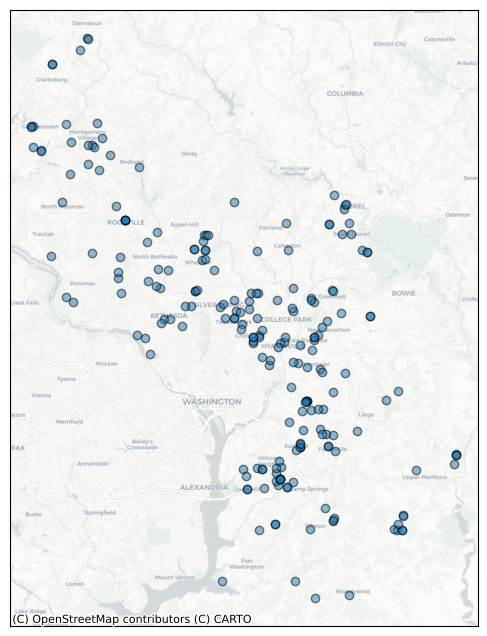

In [31]:
plot_df(wssc_alerts)

### Traffic data

Taken from MDOT website

Data definitions: https://www.roads.maryland.gov/OPPEN/Data_Dictionary.pdf

In [32]:
traffic_path = "Datasets/MDOT_SHA_Annual_Average_Daily_Traffic_locations/MDOT_SHA_Annual_Average_Daily_Traffic_(AADT)_Locations.shp"
traffic_df = geopandas.read_file(traffic_path)
traffic_df = traffic_df[(traffic_df["COUNTY_DES"] == "MONTGOMERY") | (traffic_df["COUNTY_DES"] == "PRINCE GEORGE'S")]
traffic_df = traffic_df.to_crs("EPSG:4326")
traffic_df = traffic_df[["ROADNAME", "AADT_2023", "AAWDT_2023", "geometry"]] #.rename(columns={"ROADNAME":"Road Name", "AADT_2023":"Annual Avg Daily Traffic (2023)"})
traffic_df.head()

/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,ROADNAME,AADT_2023,AAWDT_2023,geometry
2376,EISENHOWER MEMORIAL HWY,186332.0,191922.0,POINT Z (-77.17565 39.09275 0)
2377,PARK VISTA DR,2195.0,2375.0,POINT Z (-77.04283 39.10121 0)
2378,E DEER PARK DR,5375.0,5815.0,POINT Z (-77.17933 39.1375 0)
2384,WESTLAKE TERR,13795.0,14905.0,POINT Z (-77.14654 39.02694 0)
2386,SANGAMORE RD,8315.0,8985.0,POINT Z (-77.12125 38.96311 0)


### Tree Canopy data 

In [33]:
# TODO: Put Tree canopy polygon file here
# pgc_canopy = geopandas.read_file("Datasets/Tree_canopy_2023_Py.gdb")
# mc_canopy = geopandas.read_file("Datasets/Exported_TreeCanopyRasters/MC_TreeCanopyRasters_Poly.gdb", layer="tcdm2023")
# canopy_df = mc_canopy.union(pgc_canopy)
# canopy_df.head()

In [34]:
# plot_df(mc_canopy)

## Aggregating as H3 Hexagons

In [35]:
res = 7

wssc_alerts_h3_df = wssc_alerts.assign(count=1)[["count","geometry"]].h3.geo_to_h3_aggregate(resolution=res,operation="count").reset_index()
wssc_alerts_h3_df.head()

,h3_07,count,geometry
0,872aa8094ffffff,2,"POLYGON ((-76.81207 38.99271, -76.82588 38.985..."
1,872aa8098ffffff,1,"POLYGON ((-76.805 38.92056, -76.81879 38.9138,..."
2,872aa809dffffff,1,"POLYGON ((-76.77623 38.92206, -76.79003 38.915..."
3,872aa80d0ffffff,4,"POLYGON ((-76.71178 38.85295, -76.72556 38.846..."
4,872aa8400ffffff,2,"POLYGON ((-77.06621 39.0699, -77.08001 39.0631..."


In [36]:
# traffic_h3_df = traffic_df.h3.geo_to_h3_aggregate(res, operation='sum').reset_index()
# traffic_h3_df.head()


# # # traffic_h3_df.columns = traffic_h3_df.columns.map('_'.join)
# # traffic_h3_df = traffic_h3_df.h3.h3_to_geo_boundary()
# # traffic_h3_df.head()

traffic_h3_df = traffic_df.h3.geo_to_h3_aggregate(res,operation={'AADT_2023': ["median","sum", "mean"]}, return_geometry=False) #.reset_index()
traffic_h3_df.columns = traffic_h3_df.columns.map('_'.join)
traffic_h3_df = traffic_h3_df.h3.h3_to_geo_boundary().reset_index()
traffic_h3_df.head()

,h3_07,AADT_2023_median,AADT_2023_sum,AADT_2023_mean,geometry
0,872aa8080ffffff,4625.0,61090.0,7636.250000,"POLYGON ((-76.75096 38.95962, -76.76477 38.952..."
1,872aa8081ffffff,4924.5,9849.0,4924.500000,"POLYGON ((-76.73482 38.94233, -76.74863 38.935..."
2,872aa8082ffffff,7822.0,7822.0,7822.000000,"POLYGON ((-76.77975 38.95813, -76.79355 38.951..."
3,872aa8084ffffff,2275.0,16114.0,4028.500000,"POLYGON ((-76.7383 38.97841, -76.75212 38.9716..."
4,872aa8085ffffff,10045.0,344240.0,20249.411765,"POLYGON ((-76.72217 38.96111, -76.73598 38.954..."


In [37]:
canopy_h3_df = geopandas.read_file("EDA/qGIS/h3_07_tree_canopy_overlap.gpkg")
canopy_h3_df = canopy_h3_df.rename(columns={"index":"h3_07"}).drop(columns=["canopy_area"])
canopy_h3_df.head()

,h3_07,canopy_pct,geometry
0,872aa8516ffffff,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226..."
1,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724..."
2,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119..."
3,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004..."
4,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871..."


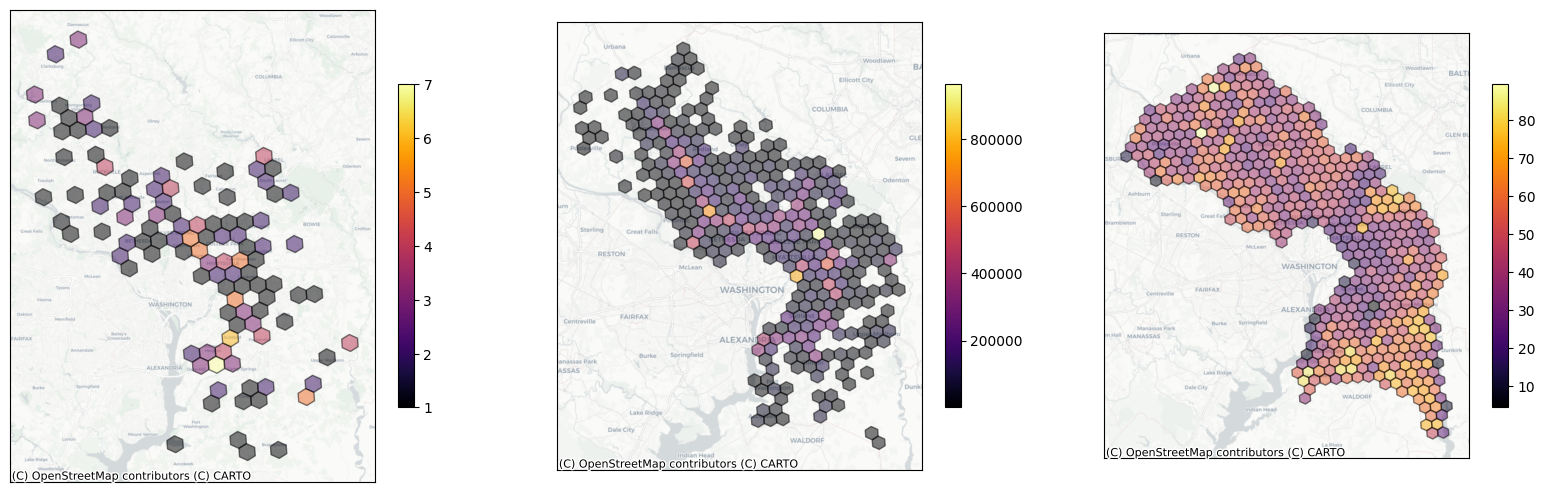

In [38]:
dfs = [wssc_alerts_h3_df, traffic_h3_df, canopy_h3_df]
cols=["count", "AADT_2023_sum", "canopy_pct"]
# cmaps = ["inferno","inferno","Greens"]
plot_df_side_by_side(dfs=dfs,columns=cols, cmap="inferno")

In [39]:
joined_df = canopy_h3_df.set_index("h3_07").join(
    traffic_h3_df.set_index("h3_07").drop(columns=["geometry"]), 
    on="h3_07"
    ).join(
        wssc_alerts_h3_df.set_index("h3_07").drop(columns=["geometry"]), on="h3_07").reset_index()

# TODO: There are some values where AAWDT_2023 is NA but count is not, would like to find a fill for AAWDT_2023 based on surrounding hexes or something
# joined_df = joined_df[(joined_df["AADT_2023_mean"].isna() & joined_df["count"].isna()) == False].fillna(0)
joined_df = joined_df.fillna(0)

joined_df.head()



,h3_07,canopy_pct,geometry,AADT_2023_median,AADT_2023_sum,AADT_2023_mean,count
0,872aa8516ffffff,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226...",0.0,0.0,0.000000,0.0
1,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",2845.0,2845.0,2845.000000,0.0
2,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",10454.5,20909.0,10454.500000,0.0
3,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1880.0,1880.0,1880.000000,0.0
4,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",3843.0,74807.0,10686.714286,1.0


## Analysis

### Exploratory Data Analysis

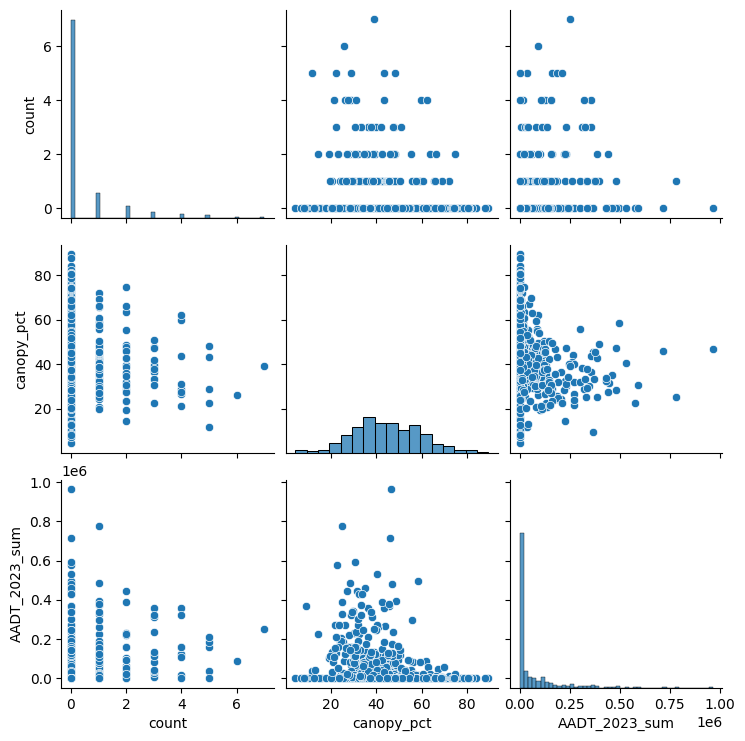

In [40]:
cols = ["count", "canopy_pct", "AADT_2023_sum"]
sns.pairplot(joined_df[cols])

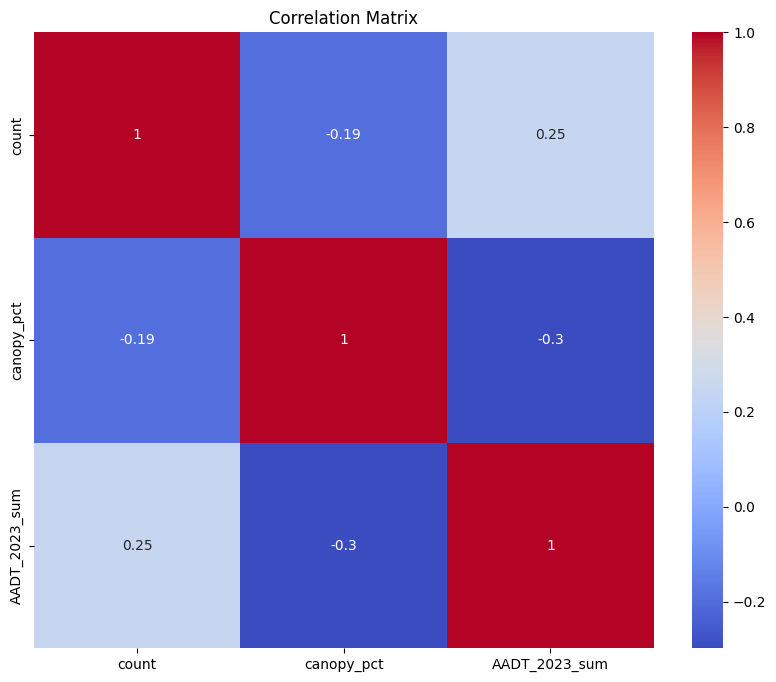

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(joined_df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

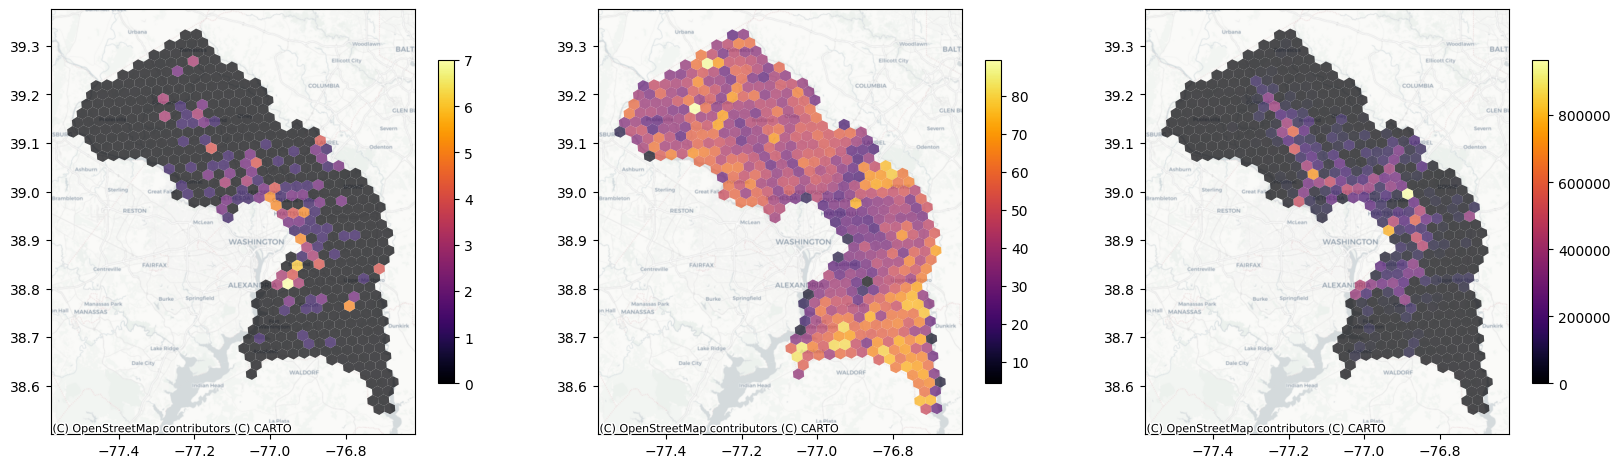

In [42]:
variables = ["count", "canopy_pct", "AADT_2023_sum"]
compare_choropleths(joined_df,variables=variables)



### Regression Analysis


In [43]:
# H0: No correlation between Canopy and traffic vs alerts

# H1: Some correlation


# Linear regression
X = joined_df[["canopy_pct", "AADT_2023_sum"]]
y = joined_df["count"]

reg = sm.OLS(y, sm.add_constant(X)).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     21.28
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.33e-09
Time:                        20:07:21   Log-Likelihood:                -711.69
No. Observations:                 517   AIC:                             1429.
Df Residuals:                     514   BIC:                             1442.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.7052      0.150      4.689      0.000       0.410       1.001
canopy_pct       -0.0091      0.003     -3.003      0.003      -0.015      -0.003
AADT_2023_sum   1.71e-06   3.69e-07      4.632      0.000    9.85e-07    2.44e-06
==============================================================================
Omnibus:                      344.498   Durbin-Watson:                   1.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3110.554
Skew:                           2.932   Prob(JB):                         0.00
Kurtosis:                      13.488   Cond. No.                     4.80e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.8e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
print("Mean: ", np.var(y))
print("Variance: ", np.var(y))

Mean:  0.994810860155113
Variance:  0.994810860155113


In [45]:
poisson_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Poisson())
poisson_result = poisson_model.fit()
print(poisson_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                  517
Model:                            GLM   Df Residuals:                      514
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -460.45
Date:                Thu, 07 May 2026   Deviance:                       664.67
Time:                        20:07:21   Pearson chi2:                 1.12e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1441
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0673      0.224      0.300



### Global Spatial Correlation

In [46]:
def prepare_geodataframe_GMI(df_aggreg, target_col = "count", num_rings = 2, 
                             flag_debug = False, flag_return_gdf = True):
    """Prepares dataframe for Global Moran's I computation, namely by
       computing z-score and geometry object for each row of the input df_aggreg"""

    df_aux = df_aggreg.copy()

    # get resolution from the hex_id of the first row (assume all the same in df_aggreg)
    # res = h3.get_resolution(df_aux.iloc[0]["h3_07"])
    res = 7
    mean_count_cell = df_aux[target_col].mean()
    stddev_count_cell = df_aux[target_col].std(ddof = 0)

    if flag_debug is True:
        msg_ = "Average number of count per H3 cell at resolution {} : {}"
        print(msg_.format(res, mean_count_cell))

    # z_score column
    df_aux["z_score"] = (df_aux[target_col] - mean_count_cell) / stddev_count_cell

    # list of cell ids on hollow rings
    for i in range(1, num_rings + 1):
        df_aux["ring{}".format(i)] = df_aux["h3_07"].apply(lambda x:
                                                            list(h3.grid_ring(h = x,
                                                                             k = i)))

    if flag_return_gdf is True:
        # make shapely geometry objects out of geojson
        df_aux["geometry_shp"] = df_aux["geometry"].apply(
                                              lambda x:
                                              geometry.Polygon(geometry.shape(x)))
        df_aux.rename(columns={"geometry": "geometry_geojson"}, inplace=True)

        geom = df_aux["geometry_shp"]
        df_aux.drop(columns=["geometry_shp"], inplace = True)
        gdf_aux = geopandas.GeoDataFrame(df_aux, crs="EPSG:4326", geometry=geom)

        return gdf_aux
    else:
        
        return df_aux

In [47]:
def compute_spatial_lags_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes spatial lags for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    gdf_aux = gdf_prepared.copy()
    gdf_aux["spatial_lag"] = np.nan

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value    

            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            # spatial lag
            spatial_lag = wij_adjusted * sum_neighbors

            gdf_aux.loc[gdf_aux["h3_07"] == hex_id, "spatial_lag"] = spatial_lag

    return gdf_aux

In [48]:
alert_prepared_GMI_df = prepare_geodataframe_GMI(joined_df, num_rings = 1, flag_debug=True)
alert_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "z_score")

Average number of count per H3 cell at resolution 7 : 0.402321083172147


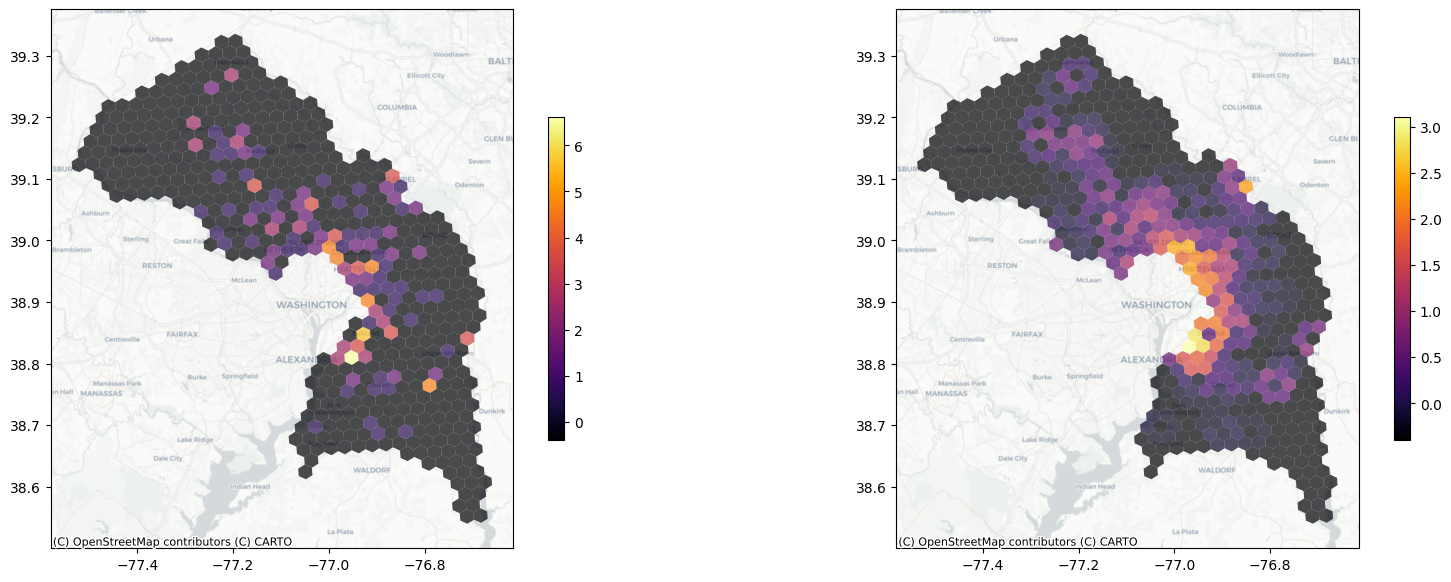

In [49]:
compare_choropleths(alert_spatial_lags_df,variables=["z_score","spatial_lag"])

In [50]:
result = sm_formula.ols(formula = "spatial_lag ~ z_score", 
                        data = alert_spatial_lags_df).fit()

params = result.params.to_dict()
print(params, "\n")
slope = params["z_score"]
print("Global Moran'I approximated by slope of the regression line:", slope)
print("\n----------------------------------------------------------------\n")

print(result.summary())

{'Intercept': 0.001616061752863563, 'z_score': 0.27298058432555317} 

Global Moran'I approximated by slope of the regression line: 0.27298058432555317

----------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:            spatial_lag   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     122.3
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.18e-25
Time:                        20:07:22   Log-Likelihood:                -433.99
No. Observations:                 517   AIC:                             872.0
Df Residuals:                     515   BIC:                             880.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                  

In [51]:
def compute_Global_Moran_I_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes Global Moran I for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    S_wijzizj = 0
    S_wij = gdf_prepared.shape[0]

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # now, in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        zi = dict_z[hex_id]
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value
            
            # update sum
            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            S_wijzizj += wij_adjusted * zi * sum_neighbors

    GMI = S_wijzizj / S_wij
    return GMI

In [52]:
def reshuffle_and_recompute_GMI(gdf_prepared, variable_col = "z_score",
                                num_permut = 999, I_observed = None,
                                alpha = 0.005, alternative = "greater",
                                flag_plot = True, flag_verdict = True):
    """Permutation inference with number of permutations given by num_permut and
       pseudo significance level specified by alpha"""

    gdf_aggreg_reshuff = gdf_prepared.copy()
    list_reshuff_I = []

    for i in range(num_permut):
        # simulate by reshuffling column
        gdf_aggreg_reshuff[variable_col] = np.random.permutation(
                                             gdf_aggreg_reshuff[variable_col].values)

        I_reshuff = compute_Global_Moran_I_using_H3(gdf_prepared = gdf_aggreg_reshuff)
        list_reshuff_I.append(I_reshuff)

    # for hypothesis testing
    list_reshuff_I.append(I_observed)

    # empirical CDF
    ecdf_GMI = sm.distributions.empirical_distribution.ECDF(list_reshuff_I, side = "left")

    percentile_observedI = stats.percentileofscore(list_reshuff_I,
                                                   I_observed,
                                                   kind='strict')
    # note: use decimal to avoid 99.9 / 100 = 0.9990000000000001
    percentile_observedI_ = float(str(decimal.Decimal(str(percentile_observedI)) / 100))

    try:
        assert(ecdf_GMI(I_observed) == percentile_observedI_)
    except Exception:
        pass
        # print(ecdf_GMI(I_observed), " vs ", percentile_observedI_)

    msg_reject_H0 = "P_sim = {:3f} , we can reject H0"
    msg_failtoreject_H0 = "P_sim = {:3f} , we fail to reject H0 under alternative {}"
        
    if alternative == "greater":
        pseudo_p_value = 1 - ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "less":
        pseudo_p_value = ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "two-tailed":
        pseudo_p_value_greater = 1 - ecdf_GMI(I_observed)
        pseudo_p_value_less = ecdf_GMI(I_observed)
        pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
        
        if flag_verdict is True:
            if (pseudo_p_value_greater < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_greater))
            elif (pseudo_p_value_less < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_less))
            else:
                pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
        
    if flag_plot is True:
        fig, ax = plt.subplots(1, 2, figsize=(20, 7),
                               gridspec_kw={'width_ratios': [2, 3]})
        gdf_prepared.plot(column=variable_col, cmap= "viridis", ax=ax[0], legend=False)

        ax[1].hist(list_reshuff_I, density=True, bins=50)
        ax[1].axvline(I_observed, color = 'red', linestyle = '--', linewidth = 3)
        fig.tight_layout()
        
    return pseudo_p_value 


In [53]:
gmi_results = compute_Global_Moran_I_using_H3(gdf_prepared = alert_prepared_GMI_df)
print("I =", gmi_results)

I = 0.2729805843255545


P_sim = 0.001000 , we can reject H0


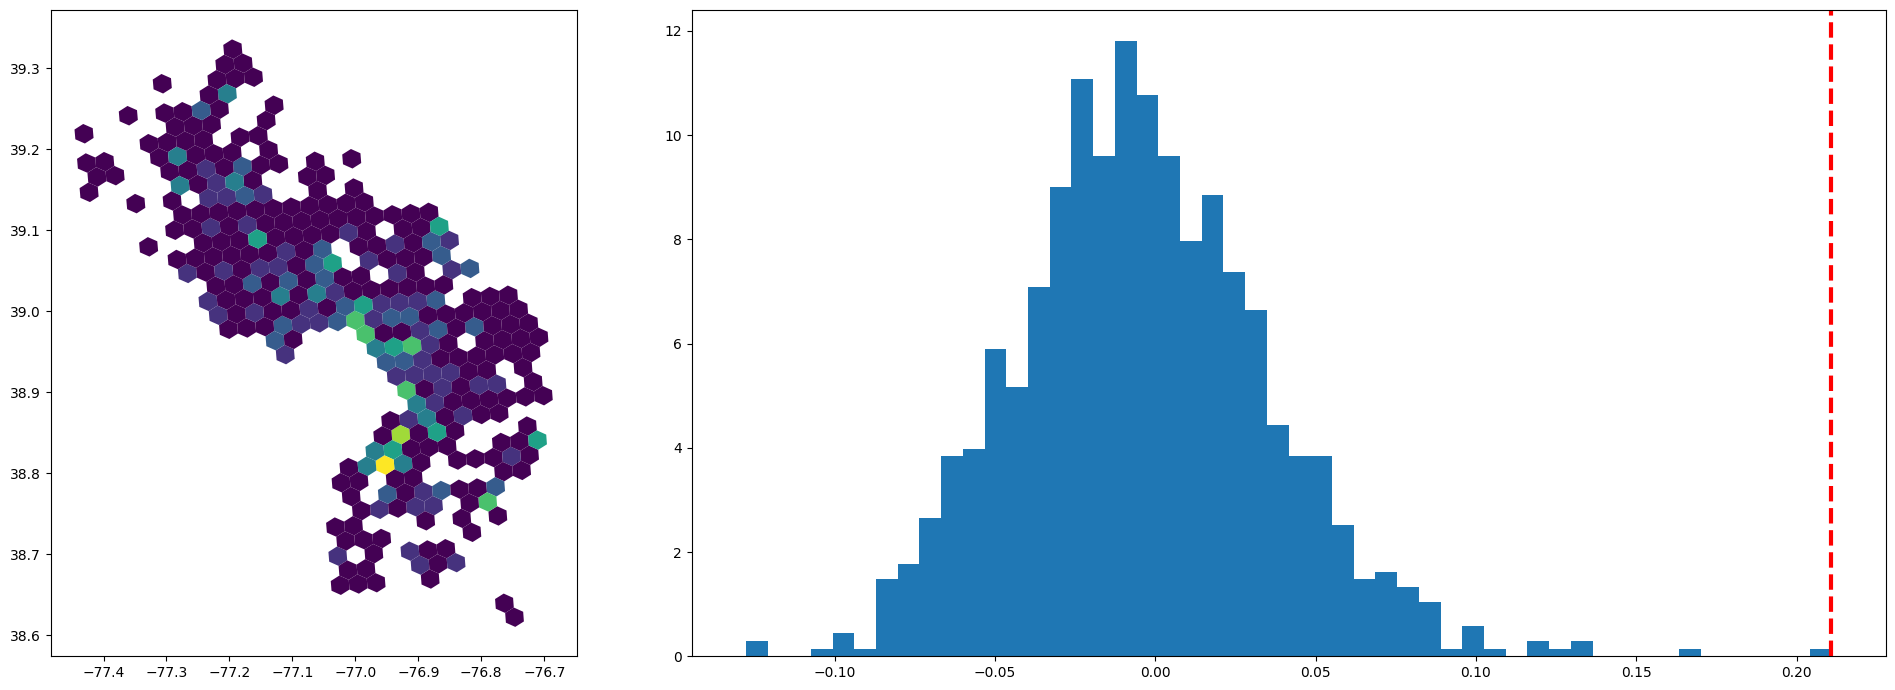

In [423]:
p_sim = reshuffle_and_recompute_GMI(gdf_prepared = alert_prepared_GMI_df,   
                                    num_permut = 999,                            
                                    I_observed = gmi_results,
                                    alternative = "two-tailed",
                                    flag_plot = True)